# 2024 수치해석 중간고사 실습 답안

In [1]:
!jupyter nbconvert --to html 12345_SIM.ipynb

[NbConvertApp] Converting notebook 12345_SIM.ipynb to html
[NbConvertApp] Writing 286110 bytes to 12345_SIM.html


# 1번 Least Square Regression (20점)

Shape memory alloy는 전류를 흘려보내고 온도 변화를 통해 수축할 수 있는 인공근육으로 사용됩니다. 하지만 주변환경에 민감하기 때문에 일정한 전류를 보내더라도 힘의 크기가 달라질 수 있습니다. 다음 데이터는 전류, 주변 온도등 센서를 통해 실제 발행한 힘 Force[N]을 시간에 따라 측정한 데이터입니다. 각 열은 다음의 6개의 특징과 예측하고 싶은 힘을 나냅니다.

```
Voltage 1 [V],Voltage 2 [V], Input current [A], Resistance 1 [ohm], Resistance 2 [ohm], Temperature [celcius],Force [N]
```

6개의 특징와 절편을 가지는 선형회귀(Linear Regression)을 해봅시다.

1) Regression에서 예측한 Force를 y축, 실제 측정된 Force를 x축으로 가지는 scatter plot을 그려보세요.

2) 위 모델을 이용하여 시간에 따른 예측한 Force과 실제 측정된 Force을 시간에 따라 그려보세요.

3) 예측된 Force에 대해 RMSE를 구하세요.

In [6]:
import numpy as np
data = np.loadtxt('static_air_test_processed.csv', delimiter=',')
data.shape

(6535, 7)

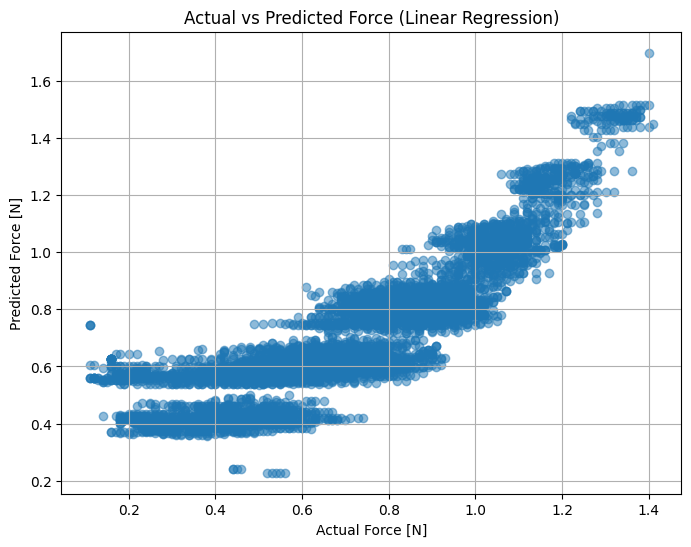

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load the data (assuming data is already loaded into 'data')
# If not, uncomment the following line:
# data = np.loadtxt('static_air_test_processed.csv', delimiter=',')

# Separate features (X) and target (y)
# Assuming the last column is the target variable 'Force [N]'
X = data[:, :-1]
y = data[:, -1]

# Add an intercept term to the features
X_with_intercept = np.c_[np.ones(X.shape[0]), X]

# Perform Linear Regression using scikit-learn
model = LinearRegression()
model.fit(X, y)

# Get predicted Force values
y_pred = model.predict(X)

# 1. Scatter plot of predicted vs actual Force
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel("Actual Force [N]")
plt.ylabel("Predicted Force [N]")
plt.title("Actual vs Predicted Force (Linear Regression)")
plt.grid(True)
plt.show()

# You can also print the coefficients and intercept
# print("Model Intercept:", model.intercept_)
# print("Model Coefficients:", model.coef_)

Regression Coefficients (including intercept) calculated using SVD:
[-1.15230389e+01  9.75373539e-01 -1.27968470e-01 -1.08535754e+01
  1.74329156e+00  9.80844216e-03 -2.88888859e-01]


## 1-1: Regression에서 예측한 Force를 y축, 실제 측정된 Force를 x축으로 가지는 scatter plot

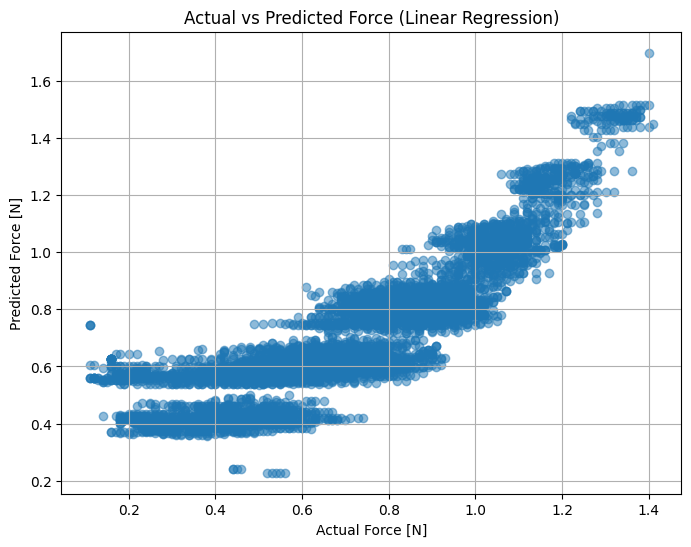

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load the data (assuming data is already loaded into 'data')
# If not, uncomment the following line:
# data = np.loadtxt('static_air_test_processed.csv', delimiter=',')

# Separate features (X) and target (y)
# Assuming the last column is the target variable 'Force [N]'
X = data[:, :-1]
y = data[:, -1]

# Add an intercept term to the features
X_with_intercept = np.c_[np.ones(X.shape[0]), X]

# Perform Linear Regression using scikit-learn
model = LinearRegression()
model.fit(X, y)

# Get predicted Force values
y_pred = model.predict(X)

# 1. Scatter plot of predicted vs actual Force
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel("Actual Force [N]")
plt.ylabel("Predicted Force [N]")
plt.title("Actual vs Predicted Force (Linear Regression)")
plt.grid(True)
plt.show()

# You can also print the coefficients and intercept
# print("Model Intercept:", model.intercept_)
# print("Model Coefficients:", model.coef_)

## 1-2 정답: 위 모델을 이용하여 시간에 따른 예측한 Force과 실제 측정된 Force을 시간에 따른 plot

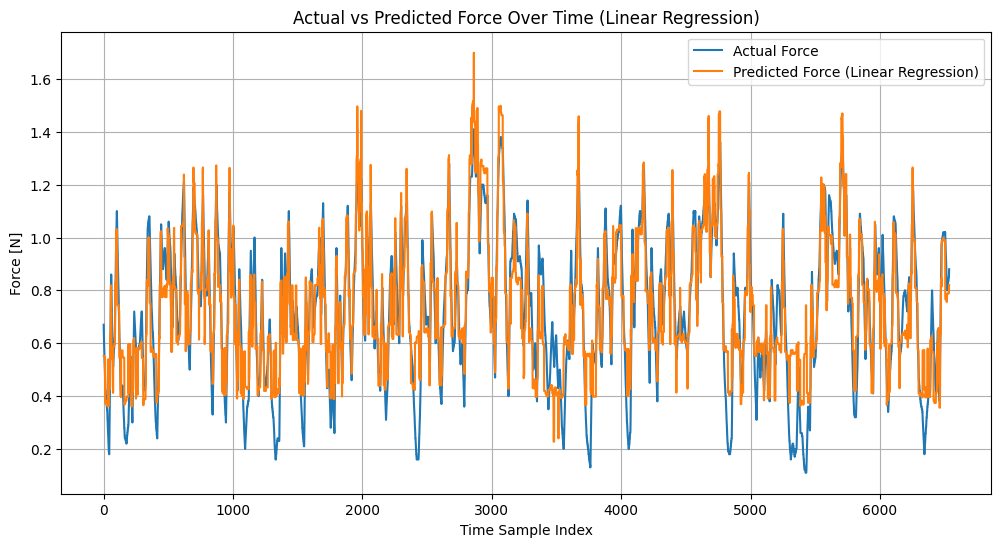

In [10]:
import matplotlib.pyplot as plt

# Assuming 'y' (actual Force) and 'y_pred' (predicted Force from scikit-learn model) are available from previous cells
# If not, make sure the cells defining these variables have been executed.

plt.figure(figsize=(12, 6))
plt.plot(y, label="Actual Force")
plt.plot(y_pred, label="Predicted Force (Linear Regression)")
plt.xlabel("Time Sample Index")
plt.ylabel("Force [N]")
plt.title("Actual vs Predicted Force Over Time (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()

## 1-3: RMSE = 0.1273273616260797

RMSE: 0.12732736162607938


## 1번 문제 답안
## 1-2: 아래 그래프

# 2번 Numerical Solution of Equation (10점)
다음 함수의 근을 수치해석을 통해 구하세요.

$f(x)=e^x-4x-2$

Newton-Raphson 방법을 사용하여 구하세요. 초기 가정으로 $x_0=0.2$를 사용하고 근사상대오차 $e<10^{-6}$ (0.0001%) 까지 계산하세요.


Initial guess: x0 = 0.2

Converged after 4 iterations.
Approximate root: x = -0.3181213808104406
Approximate relative error: 2.4713349245076417e-08


In [15]:
import numpy as np

# Define the function f(x)
def func(x):
    return np.exp(x) - 4*x - 2

# Define the derivative of f(x), f'(x)
def func_p(x):
    return np.exp(x) - 4

N = 10; x0 = 0.2; tol = 1e-6; xn = x0
for i in range(N):
    xnn = xn - func(xn)/func_p(xn)
    error = (xnn - xn)/xnn
    print(f'n:{i}, xn:{xn:.6f}, xn+1:{xnn:.6f}, error:{error:.6e}')
    xn = xnn
    if abs(error) < tol:
        break

print(f'Solution is {xn:.6f}')

n:0, xn:0.200000, xn+1:-0.368127, error:1.543290e+00
n:1, xn:-0.368127, xn+1:-0.318387, error:-1.562249e-01
n:2, xn:-0.318387, xn+1:-0.318121, error:-8.360667e-04
n:3, xn:-0.318121, xn+1:-0.318121, error:-2.471335e-08
Solution is -0.318121


## 2번 문제 정답: <b> -0.318121

# 3번 Principal Component Analysis (30점)

## 3-1번 문제
수업 실습2에서 38번 사람의 첫번째 얼굴을 특이얼굴를 이용해서 재구성한다고 할 때 첫번째 특이얼굴에 대한 주성분 값을 구하세요 (소수 셋째자리까지).


/tmp/ipython-input-3441649772.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
/tmp/ipython-input-3441649772.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


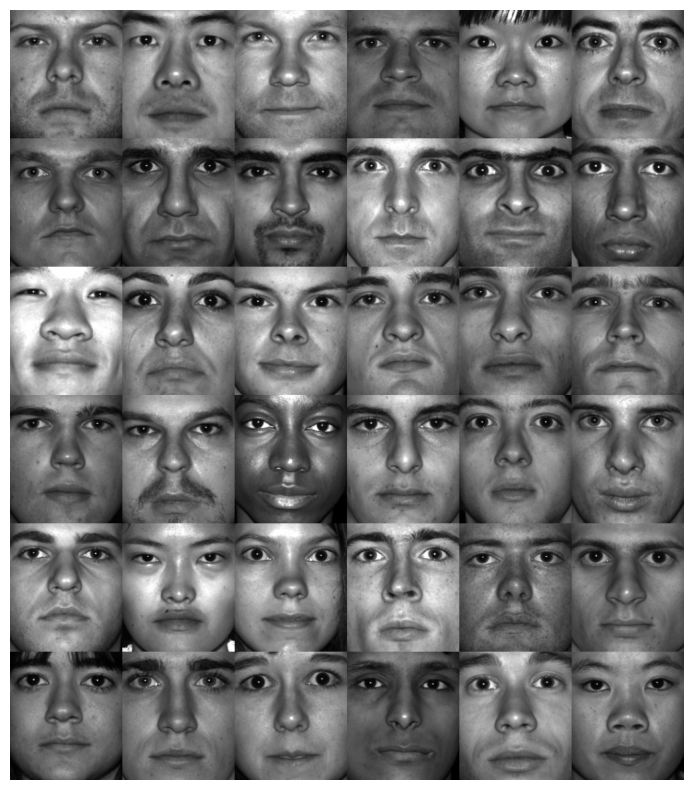

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.io
plt.rcParams['figure.figsize'] = [10, 10]
plt.rcParams.update({'font.size': 18})

from urllib.request import urlretrieve
urlretrieve('https://jooyongsim.github.io/numerical2023/src/allFaces.mat','allFaces.mat')

mat_contents = scipy.io.loadmat('allFaces.mat')
faces = mat_contents['faces']
m = int(mat_contents['m'])
n = int(mat_contents['n'])
nfaces = np.ndarray.flatten(mat_contents['nfaces'])

allPersons = np.zeros((n*6,m*6))
count = 0

for j in range(6):
    for k in range(6):
        allPersons[j*n : (j+1)*n, k*m : (k+1)*m] = np.reshape(faces[:,np.sum(nfaces[:count])],(m,n)).T
        count += 1

img = plt.imshow(allPersons)
img.set_cmap('gray')
plt.axis('off')
plt.show()

/tmp/ipython-input-1013035180.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
/tmp/ipython-input-1013035180.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


ValueError: shapes (32256,) and (2410,) not aligned: 32256 (dim 0) != 2410 (dim 0)

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.io
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams.update({'font.size': 18})
xx
mat_contents = scipy.io.loadmat('allFaces.mat')
faces = mat_contents['faces']
m = int(mat_contents['m'])
n = int(mat_contents['n'])
nfaces = np.ndarray.flatten(mat_contents['nfaces'])

# We use the first 36 people for training data
trainingFaces = faces[:,:np.sum(nfaces[:36])].T
avgFace = np.mean(trainingFaces,axis=0) # size n*m by 1

avgFace.shape

/tmp/ipython-input-1007448525.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
/tmp/ipython-input-1007448525.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


(32256,)

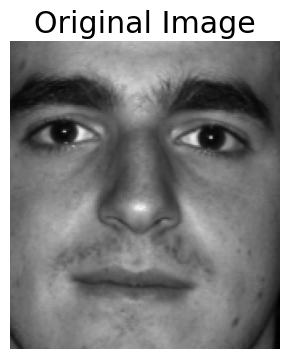

In [23]:
## Now show eigenface reconstruction of image that was omitted from test set
plt.rcParams['figure.figsize'] = [4, 4]
testFace = faces[:,np.sum(nfaces[:37])] # First face of person 38

plt.imshow(np.reshape(testFace,(m,n)).T)
plt.set_cmap('gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [24]:
X = trainingFaces - avgFace
U, S, VT = np.linalg.svd(X,full_matrices=False)

In [25]:
testFaceMS = testFace - avgFace

testFaceMS @ VT[:3,:].T
testFaceMS @ VT.T[:,:3]


array([-5129.56647228, -1840.87287875,  -813.12446736])

### 3-1번 문제 답: 주성분의 값 = -5129.566


/tmp/ipython-input-756795857.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
/tmp/ipython-input-756795857.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


38번 사람의 첫 번째 얼굴에 대한 첫 번째 특이 얼굴의 주성분 값: -5186.236


## 3-2번 문제

수업 실습3의 “sensor_array_data.csv”의 6가지 다른 몸의 움직임에 대해서 각각 30번 측정한 센서 데이터에 대해서 PCA를 수행하고 다음 "sensor_data_test.csv" 데이터가 어떤 동작인지 찾으세요.


In [36]:
import pandas as pd

sensor_data = pd.read_csv('https://raw.githubusercontent.com/jooyongsim/numerical2023/refs/heads/main/sensor_array_data.csv', header=None)
group_data = pd.read_csv('https://raw.githubusercontent.com/jooyongsim/numerical2023/refs/heads/main/sensor_array_data_grp.csv', header=None)
print("sensor_array_data_df loaded successfully.")

sensor_array_data_df loaded successfully.


(180, 180) (180,) (776, 776)


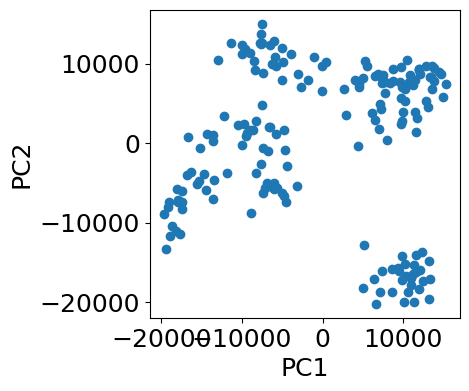

In [37]:
import numpy as np
sensor_data = pd.read_csv('https://raw.githubusercontent.com/jooyongsim/numerical2023/refs/heads/main/sensor_array_data.csv', header=None)

# 1. Mean Centering A-> B
sensor_data_mean = sensor_data - sensor_data.mean(axis=0)
sensor_data_mean = np.array(sensor_data_mean)
# 2. Compute SVD of B
U,S,VT = np.linalg.svd(sensor_data_mean)
print(U.shape, S.shape, VT.shape)
# 3. T = BV
PC = sensor_data_mean@VT.T

import matplotlib.pyplot as plt
plt.plot(PC[:,0], PC[:,1], 'o')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

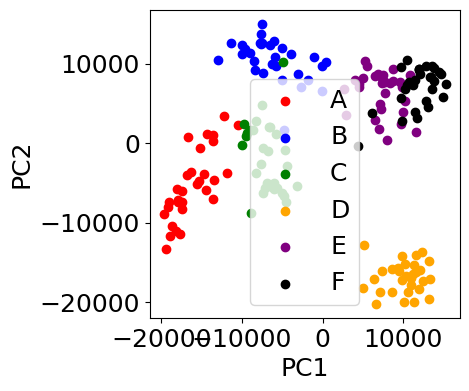

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ... (Previous code from the provided context) ...

# Assuming group_data contains the group labels (A, B, C, D, E, F)
group_labels = group_data.iloc[:, 0]
group_labels = np.array(group_labels)


# Create a color map for the groups
color_map = {'A': 'red', 'B': 'blue', 'C': 'green', 'D': 'orange', 'E': 'purple', 'F': 'black'}

# Plot PC1 and PC2 with different colors for each group
for group_label in np.unique(group_labels):
  indices = np.where(group_labels == group_label)[0]
  plt.scatter(PC[indices, 0], PC[indices, 1], color=color_map[group_label], label=group_label)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [42]:
sensor_data.shape

(180, 776)

In [49]:
test

(776, 1)

In [50]:
sensor_data.mean(axis=0).shape

(776,)

In [53]:
sensor_data_test_df = pd.read_csv('sensor_data_test.csv', header=None)
test = np.array(sensor_data_test_df)
test_meaned = test[:,0]- sensor_data.mean(axis=0)
pc = test_meaned@VT.T[:,:2]
pc.shape


(2,)

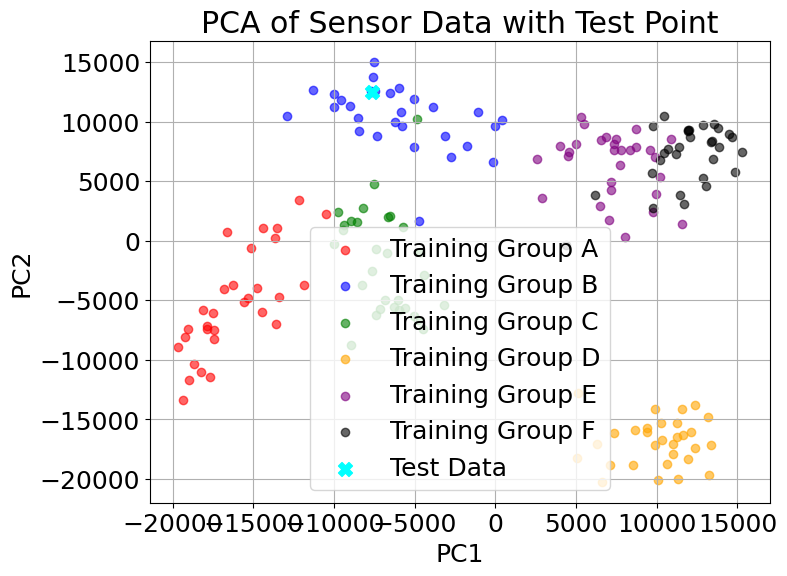

### 3-2번 문제 정답: 동작 = B

## 3-3번 문제
위 데이터에 대해서 동작A와 동작B를 PC2=0을 기준으로 분류한다고 했을 때동작A와 동작B의 예측 정확도를 구하세요.


In [60]:
import numpy as np

# Assuming PC (training data PCs) and group_labels (training data group labels)
# are available from previous cells.
# If not, make sure the cells defining these variables have been executed.

# Extract PC2 values for all training data points
pc2_values = PC[:, 1]

# Get the indices for groups A and B
indices_A = np.where(group_labels == 'A')[0]
indices_B = np.where(group_labels == 'B')[0]

# Get PC2 values for groups A and B
pc2_A = pc2_values[indices_A]
pc2_B = pc2_values[indices_B]

# Classification rule: if PC2 > 0, predict A; if PC2 <= 0, predict B

# Predictions for Group A
# If PC2_A > 0, prediction is correct (A). If PC2_A <= 0, prediction is incorrect (B).
predictions_A_correct = np.sum(pc2_A < 0)
total_A = len(pc2_A)
accuracy_A = (predictions_A_correct / total_A) * 100 if total_A > 0 else 0

# Predictions for Group B
# If PC2_B <= 0, prediction is correct (B). If PC2_B > 0, prediction is incorrect (A).
predictions_B_correct = np.sum(pc2_B >= 0)
total_B = len(pc2_B)
accuracy_B = (predictions_B_correct / total_B) * 100 if total_B > 0 else 0

print(f"동작 A 예측 정확도: {accuracy_A:.2f}%")
print(f"동작 B 예측 정확도: {accuracy_B:.2f}%")

동작 A 예측 정확도: 80.00%
동작 B 예측 정확도: 100.00%


### 3-3번 문제 정답: 동작A 정확도 80%, 동작 B 정확도 100%

## 3-4번 문제
수업 실습3의 Eigen Face 코드에서 dog.jpg의 rank-1000 approximation 이미지를 Eigen Face의 Principal Components를 이용해 그리세요.


In [61]:
!wget https://raw.githubusercontent.com/jooyongsim/numerical2023/refs/heads/main/dog.jpg

--2025-10-20 07:40:39--  https://raw.githubusercontent.com/jooyongsim/numerical2023/refs/heads/main/dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 888111 (867K) [image/jpeg]
Saving to: ‘dog.jpg’

dog.jpg             100%[===================>] 867.30K  5.55MB/s    in 0.2s    

2025-10-20 07:40:39 (5.55 MB/s) - ‘dog.jpg’ saved [888111/888111]



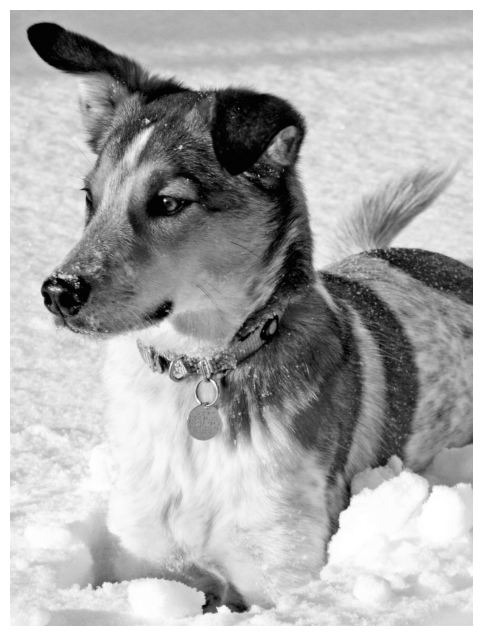

In [65]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os
plt.rcParams['figure.figsize'] = [16, 8]

from urllib.request import urlretrieve

urlretrieve('https://github.com/jooyongsim/numerical2025/blob/main/dog.jpg?raw=true','dog.jpg')

A = imread(os.path.join('dog.jpg'))
X = np.mean(A, -1); # Convert RGB to grayscale

img = plt.imshow(X)
img.set_cmap('gray')
plt.axis('off')
plt.show()

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.io
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams.update({'font.size': 18})

mat_contents = scipy.io.loadmat('allFaces.mat')
faces = mat_contents['faces']
m = int(mat_contents['m'])
n = int(mat_contents['n'])
nfaces = np.ndarray.flatten(mat_contents['nfaces'])

# We use the first 36 people for training data
trainingFaces = faces[:,:np.sum(nfaces[:36])].T
avgFace = np.mean(trainingFaces,axis=0) # size n*m by 1

avgFace.shape

X = trainingFaces - avgFace
U, S, VT = np.linalg.svd(X,full_matrices=False)

/tmp/ipython-input-2029198667.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
/tmp/ipython-input-2029198667.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


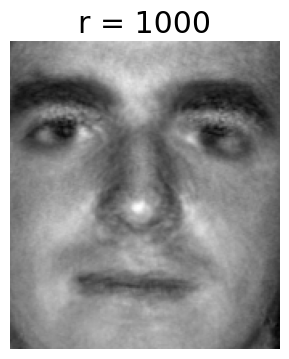

In [67]:
testFaceMS = testFace - avgFace
r_list = [1000]

plt.rcParams['figure.figsize'] = [4, 4]

for r in r_list:
    Z_r = testFaceMS @ VT[:r,:].T # r principal components (# = r)
    reconFace = avgFace + Z_r @ VT[:r,:] # reconstruction using r eigen faces and r principal components
    img = plt.imshow(np.reshape(reconFace,(m,n)).T)
    img.set_cmap('gray')
    plt.title('r = ' + str(r))
    plt.axis('off')
    plt.show()